## Reproducing The Original Expression Notebook

This section shows how to reproduce the interval-based inference path used by the original expression notebook.

The important difference from the simpler TSS-centered examples is that we do not fetch a symmetric window around the TSS. Instead, we construct the same kind of sequence used by the original dataset code:

- take `num_before * token_len_for_fetch` base pairs upstream of the TSS;
- continue from the TSS through the gene interval up to `TES`;
- mark the TSS position as an integer center inside the constructed sequence.

For this model configuration:

```python
num_before = 250
token_len_for_fetch = 15

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.contexts import Genome
from gena_expression.inference import SequenceModel

### Paths And Model Configuration

This cell defines all local paths needed to reproduce the original inference setup.

The paths marked with `CHANGE THIS LINE` are machine-specific and should be updated before running the notebook. The most important values are:

- `GENA_LM_ROOT`: root of the original `GENA_LM` repository (should have models dir with encoder and decoder);
- `MODEL_CLS`: path to `expression_model_final.py::ExpressionCounts`;
- `MODEL_CHECKPOINT`: trained model weights;
- `MODEL_CONFIG`: Hydra config used to instantiate the model;
- `DNA_TOKENIZER`: tokenizer used for genomic DNA;
- `DESCRIPTION_TOKENIZER`: tokenizer used for condition descriptions;
- `GENOME_FASTA`: hg38 FASTA;
- `GENOME_ANNOTATION`: optional GTF annotation used for genomic features.

In [2]:
# Paths and constants used by later cells

from pathlib import Path

GENA_LM_ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS}::ExpressionCounts"

MODEL_CHECKPOINT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "models" / "expression_model_latest" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DATA_DIR = Path("../data").resolve()
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:5"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__() # CHANGE THIS LINE

In [3]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=250,
    desc_max_seq_len=510,
    token_len_for_fetch=15,
    device=DEVICE,
)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py:261: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

### Load A Small Gene Subset

The original expression notebook works from interval tables. Here we load the forward-strand interval table and keep only the first five rows to make the example quick to run.

Each row provides the genomic coordinates needed to build a model input:

- chromosome;
- TSS;
- TES;
- strand;
- gene name.

The same approach can be applied to the full interval table

In [4]:
intervals_dir = '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/intervals'
forward_intervals = f'{intervals_dir}/human.train.forward.csv'
reverse_intervals = f'{intervals_dir}/human.train.reverse.csv'

subset = pl.read_csv(forward_intervals, separator='\t').head(5)

In [5]:
subset.with_columns(length = pl.col.TES-pl.col.TSS)

chrom,start,end,transcript_id,gene_strand,gene_id,gene_name,chromosome,gene_start,gene_end,transcript_name,transcript_start,transcript_end,TSS,TES,gene_id_unversioned,split,length
str,i64,i64,str,str,str,str,str,i64,i64,str,i64,i64,i64,i64,str,str,i64
"""chr1""",779056,779056,"""ENST00000429505.5""","""+""","""ENSG00000237491.8""","""AL669831.5""","""chr1""",778770,810060,"""AL669831.5-205""",779056,804875,779056,804875,"""ENSG00000237491""","""train""",25819
"""chr1""",817371,817371,"""ENST00000326734.2""","""+""","""ENSG00000177757.2""","""FAM87B""","""chr1""",817371,819837,"""FAM87B-201""",817371,819837,817371,819837,"""ENSG00000177757""","""train""",2466
"""chr1""",904834,904834,"""ENST00000607769.1""","""+""","""ENSG00000272438.1""","""AL645608.6""","""chr1""",904834,915976,"""AL645608.6-201""",904834,915976,904834,915976,"""ENSG00000272438""","""train""",11142
"""chr1""",911435,911435,"""ENST00000448179.1""","""+""","""ENSG00000230699.2""","""AL645608.2""","""chr1""",911435,914948,"""AL645608.2-201""",911435,914948,911435,914948,"""ENSG00000230699""","""train""",3513
"""chr1""",914171,914171,"""ENST00000398216.2""","""+""","""ENSG00000241180.1""","""AL645608.4""","""chr1""",914171,914971,"""AL645608.4-201""",914171,914971,914171,914971,"""ENSG00000241180""","""train""",800


### Genome And Condition Descriptions

`Genome(...)` opens the reference FASTA and optional GTF annotation. The annotation is not required for expression prediction itself, but it is useful when keeping feature metadata on returned sequences.

`DescriptionLookup(...)` selects the exact metadata JSON files used as condition descriptions. Here we define three cell types and constrain each one by its expected `id`, so the lookup is deterministic.

The resulting `conditions` dictionary maps each cell type name to a `Condition` object that can be passed directly into the model.

In [6]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=["K562", "HepG2", "H1"],
    K562={"id": "ENCFF578UUD"},
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},
)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/genome.py:423: RuntimeWarning: Plain GTF/GFF annotations are not supported directly for fast interval queries; using existing compressed annotation /workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz. debug={'plain_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf', 'compressed_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz'}
  return _TabixGtfAnnotation(cls._ensure_tabix_gtf(path))
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expr

In [7]:
conditions = {
    cell_type: Condition(name=cell_type, description=lookup[cell_type])
    for cell_type in lookup.keys()
}
tss_tes_coords = {row['gene_name'] : (row['chrom'], row['TSS'], row['TES'], row['gene_strand']) for row in subset.iter_rows(named=True)}

In [8]:
tss_tes_coords

{'AL669831.5': ('chr1', 779056, 804875, '+'),
 'FAM87B': ('chr1', 817371, 819837, '+'),
 'AL645608.6': ('chr1', 904834, 915976, '+'),
 'AL645608.2': ('chr1', 911435, 914948, '+'),
 'AL645608.4': ('chr1', 914171, 914971, '+')}

### Build Interval-Based Sequences

This is the key reproduction step.

For each `(cell type, gene)` pair, we fetch the genomic sequence from:

```python
TSS - token_len_for_fetch * num_before
```

to:

```python
TES
```

This mirrors the original dataset-style input: a fixed upstream region before the TSS plus the downstream gene interval.

We pass:

```python
center = 15 * 250
```

later because the TSS is no longer at the middle of the sequence. It is exactly `3750` bp from the beginning of the constructed interval.

Using `genome.sequence(...)` here is important. It gives direct control over the interval boundaries, unlike `sequence_around(...)`, which creates a symmetric window around a center point.

In [9]:
results = []

batch_conditions=[]
sequences = []
for cell_type in lookup.keys():
    for gene, (chrom, tss, tes, strand) in tss_tes_coords.items():
        sequence = genome.sequence(
                chrom=chrom,
                start=tss-15*250, #token_len_for_fetch * num_before
                end=tes,
                strand=strand,
                include_features=True,
                name=gene,
            )
        sequences.append(sequence)
        batch_conditions.append(conditions[cell_type])

In [10]:
len(sequences)

15

### Run Batch Prediction

`predict_multiple_sequences(...)` receives all sequence-condition pairs at once.

Here we use:

```python
grouping = "no_grouping"
```

because this path is meant to reproduce another notebook as directly as possible. In this mode, each `(sequence, condition)` pair is forwarded independently, avoiding extra shortcut behavior from grouped repeated sequences or repeated conditions.

Each returned object is an `ExpressionPrediction`. The final loop extracts:

- cell type name;
- description ID;
- gene name;
- scalar predicted expression value.

In [ ]:
batch_predictions = model.predict_multiple_sequences(
    sequences=sequences,
    conditions=batch_conditions,
    center=15 * 250,
    grouping="no_grouping",
    max_records_per_forward=5,
    preprocessing_workers=0,
    prefetch_batches=0,
    return_tokens=True,
)

In [ ]:
results = []
batch_predictions = model.predict_multiple_sequences(
    sequences=sequences,
    conditions=batch_conditions,
    center=15*250,
    grouping='no_grouping',
    return_tokens=True,
    max_records_per_forward=5
)

for batch_prediction in batch_predictions:
    results.append(
        (
            batch_prediction.condition.name,
            batch_prediction.condition.description['id'],
            batch_prediction.sequence.name,
            float(batch_prediction.outputs["expression"].flatten()[0]),
        )
    )

Predicting sequences: 100%|██████████| 3/3 [00:00<00:00,  7.38batch/s]


In [40]:
results

[('K562', 'ENCFF578UUD', 'AL669831.5', 2.21875),
 ('K562', 'ENCFF578UUD', 'FAM87B', 0.048095703125),
 ('K562', 'ENCFF578UUD', 'AL645608.6', 0.10302734375),
 ('K562', 'ENCFF578UUD', 'AL645608.2', 0.0118408203125),
 ('K562', 'ENCFF578UUD', 'AL645608.4', 0.08154296875),
 ('HepG2', 'ENCFF588KDY', 'AL669831.5', 1.21875),
 ('HepG2', 'ENCFF588KDY', 'FAM87B', 0.025634765625),
 ('HepG2', 'ENCFF588KDY', 'AL645608.6', 0.10400390625),
 ('HepG2', 'ENCFF588KDY', 'AL645608.2', 0.0791015625),
 ('HepG2', 'ENCFF588KDY', 'AL645608.4', 0.201171875),
 ('H1', 'ENCFF081FQX', 'AL669831.5', 0.49609375),
 ('H1', 'ENCFF081FQX', 'FAM87B', 0.0031890869140625),
 ('H1', 'ENCFF081FQX', 'AL645608.6', 0.09814453125),
 ('H1', 'ENCFF081FQX', 'AL645608.2', 0.03955078125),
 ('H1', 'ENCFF081FQX', 'AL645608.4', 0.0556640625)]

In [67]:
def plot_results(results:list):
    df = pd.DataFrame(results)
    df.columns = ['Cell Type', 'ID', 'Gene', 'Expression']
    print (df)
    df.drop(columns=['ID'], inplace=True)
    plt.figure(figsize=(10,4))
    sns.barplot(x='Gene', y='Expression', hue='Cell Type', data=df, palette='gray')
    plt.xlabel('Gene', fontsize=12)
    plt.ylabel('Expression (log(TPM+1))', fontsize=12)
    plt.grid(True, axis='y')
    plt.show()

   Cell Type           ID        Gene  Expression
0       K562  ENCFF578UUD  AL669831.5    2.218750
1       K562  ENCFF578UUD      FAM87B    0.051758
2       K562  ENCFF578UUD  AL645608.6    0.106934
3       K562  ENCFF578UUD  AL645608.2    0.032227
4       K562  ENCFF578UUD  AL645608.4    0.095215
5      HepG2  ENCFF588KDY  AL669831.5    1.218750
6      HepG2  ENCFF588KDY      FAM87B    0.022583
7      HepG2  ENCFF588KDY  AL645608.6    0.095215
8      HepG2  ENCFF588KDY  AL645608.2    0.074219
9      HepG2  ENCFF588KDY  AL645608.4    0.189453
10        H1  ENCFF081FQX  AL669831.5    0.478516
11        H1  ENCFF081FQX      FAM87B    0.011353
12        H1  ENCFF081FQX  AL645608.6    0.091309
13        H1  ENCFF081FQX  AL645608.2    0.045898
14        H1  ENCFF081FQX  AL645608.4    0.047852


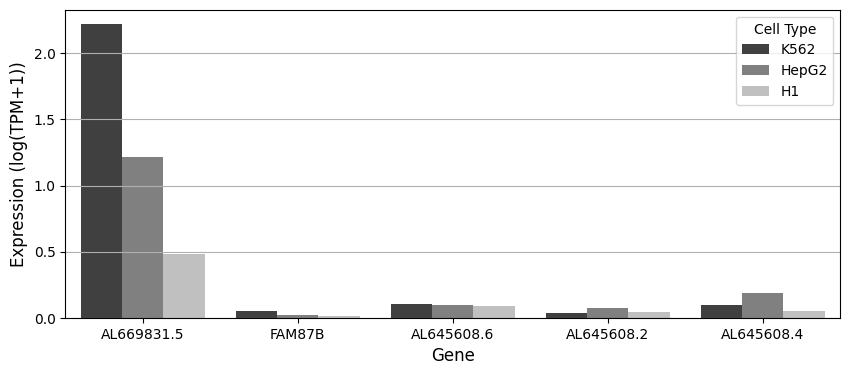

In [68]:
plot_results(results)